In [1]:
import torch
import pandas as pd
import json
from tqdm import tqdm
from config import INDEX_UNTIL, LAM_VALUES, REAL_DIR, TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE
import gc
from fid import (
    build_prompt_map, build_clip_model, build_feat_model,
    compute_real_stats, compute_fid_score, compute_clip, sanity_check
)
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
INDEX_UNTIL = 5

replica_exchanges = [True, False]

PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_test")
TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_test")

LAM_VALUES = [ 0.95, 0.9, 0.98]
LAM_FULL = LAM_VALUES + [1.0 + (1.0-l) for l in LAM_VALUES]

SWAP_ALGORITHM = {
	"n_replicas": 4,
	"p_ratio": "p",
	"even_indices": [2,  8, 12,  16],   # t ≈ 870, 763, 648, 536
	"odd_indices":  [4,  10, 14,  18],
	"debug": True,
}

# ── Load prompts once ─────────────────────────────────────────────────────────
df = pd.read_csv(PROMPTS_FILE, dtype={"original_idx": str})
prompts = df["text"].tolist()[:INDEX_UNTIL]
print(f"Loaded {len(prompts)} prompts")

Loaded 5 prompts


In [3]:
gc.collect()
torch.cuda.empty_cache()

In [4]:
from diffusers import StableDiffusion3Pipeline

# ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

In [5]:
for replica_exchange in replica_exchanges:

	if replica_exchange:
		BASE_OUTPUT_DIR = PT_TSR_DIR
		LAM_ALL = LAM_VALUES
	else:
		BASE_OUTPUT_DIR = TSR_DIR
		LAM_ALL = LAM_FULL

	# ── Sweep ─────────────────────────────────────────────────────────────────────
	for tsr_lam in LAM_ALL:
		k_str = f"lam{tsr_lam:.3f}".replace(".", "p")   # e.g. "k0p950" — safe for filenames
		output_dir = BASE_OUTPUT_DIR / k_str
		checkpoint_file = output_dir / "completed.json"
		output_dir.mkdir(parents=True, exist_ok=True)

		if replica_exchange:
			k_str_flipped = f"lam{2.0-tsr_lam:.3f}".replace(".", "p")   # e.g. "k0p950" — safe for filenames
			output_dir_flipped = BASE_OUTPUT_DIR / k_str_flipped
			checkpoint_file_flipped = output_dir_flipped / "completed.json"
			output_dir_flipped.mkdir(parents=True, exist_ok=True)

		existing = list(output_dir.glob("*.png"))
		completed = set(range(len(existing)))
		if existing:
			print(f"\n[k={tsr_lam}] Resuming — {len(completed)}/{len(prompts)} done")
		else:
			completed = set()
			print(f"\n[k={tsr_lam}] Starting fresh")

		for idx, prompt in enumerate(tqdm(prompts, desc=f"k={tsr_lam}")):
			if idx in completed:
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED + idx)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{df.iloc[idx]['original_idx']}.png"
			images[1].save(out_path, icc_profile=None)

			if replica_exchange:
				out_path = output_dir_flipped / f"{df.iloc[idx]['original_idx']}.png"
				images[2].save(out_path, icc_profile=None)
			
			del images
			torch.cuda.empty_cache()

			completed.add(idx)
			if idx % 50 == 0:
				checkpoint_file.write_text(json.dumps(list(completed)))


		checkpoint_file.write_text(json.dumps(list(completed)))
		print(f"[k={tsr_lam}] Done — {len(completed)} images saved to {output_dir}")

	print("\n All k values complete.")


[k=0.95] Starting fresh


k=0.95:   0%|          | 0/5 [00:00<?, ?it/s]

We will be running with replica swaps with 4 replicas


/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/diffusers/src/diffusers/pipelines/stable_diffusion_3/pipeline_stable_diffusion_3.py:1030: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scaled = [latents * torch.sqrt(torch.tensor(lam_ladder[i])) for i in range(n_replicas)]


 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 1000.00
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 988.27
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 975.98
Time 975.98 swap btwn source 0.95 and target 0.75 accept 0.983 std 0.960
Time 975.98 swap btwn source 1.25 and target 1.05 accept 1.000 std 0.960
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 963.08
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 949.53
Time 949.53 swap btwn source 1.05 and target 0.95 accept 0.990 std 0.937
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 935.28
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 920.28
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 904.45
 We tsr by 0.75
 We tsr by 0.95
 We tsr by 1.05
 We tsr by 1.25
t is 887.74
Time 887.74 swap btwn source 0.95 and target 0.75 accept 0.973 std 0.890
Time 887.74 swap btwn s

...

[k=0.98] Done — 5 images saved to /n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_test/lam0p980

 All k values complete.

[k=0.95] Resuming — 3/5 done


k=0.95:   0%|          | 0/5 [00:00<?, ?it/s]

 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95
 We tsr by 0.95


k=0.95:  60%|██████    | 3/5 [00:10<00:06,  3.39s/it]


IndexError: list index out of range

In [6]:
device = "cuda"

# ── Initialize models once ────────────────────────────────────────────────────
prompt_map                 = build_prompt_map()
clip_model, clip_processor = build_clip_model(device)
feat_model                 = build_feat_model(device)
mu_real, sigma_real        = compute_real_stats(feat_model, device, n=INDEX_UNTIL)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Computing real image features...


/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.36s/it]

Real features computed from 5 images.



In [7]:
# ── Compute ───────────────────────────────────────────────────────────────────
tsr_results = {alg: {} for alg in replica_exchanges}
TSR_DIRS = []

for alg in replica_exchanges:
	if alg == False:
		TSR_DIRS.append(TSR_DIR)
	elif alg == True:
		TSR_DIRS.append(PT_TSR_DIR)

for tsr_lam in LAM_FULL :
    lam_str = f"lam{tsr_lam:.3f}".replace(".", "p")
    print(f"\n── {lam_str} ──")

    for alg_idx, tsr_samples_dir in enumerate(TSR_DIRS):
        alg = replica_exchanges[alg_idx]
        samples_dir = (TSR_DIR if tsr_lam == 1.0 else tsr_samples_dir) / lam_str

        fid_val  = compute_fid_score(samples_dir, feat_model, mu_real, sigma_real, device, n=INDEX_UNTIL)
        clip_val = compute_clip(samples_dir, tsr_lam, prompt_map, clip_model, clip_processor, device, index_until=INDEX_UNTIL)
        tsr_results[alg][tsr_lam] = (fid_val, clip_val)
        print(f"[{alg}]  lam={tsr_lam:.3f}  FID={fid_val:.4f}  CLIP={clip_val:.4f}")


── lam0p950 ──


CLIP lam=0.95: 100%|██████████| 5/5 [00:00<00:00, 19.66it/s]


[True]  lam=0.950  FID=201.0527  CLIP=33.9675


CLIP lam=0.95: 100%|██████████| 3/3 [00:00<00:00, 21.05it/s]


[False]  lam=0.950  FID=267.1997  CLIP=30.8047

── lam0p900 ──


...

[False]  lam=1.100  FID=270.5983  CLIP=30.7975

── lam1p020 ──


CLIP lam=1.02: 100%|██████████| 5/5 [00:00<00:00, 22.35it/s]


[True]  lam=1.020  FID=195.7315  CLIP=33.8068


CLIP lam=1.02: 100%|██████████| 3/3 [00:00<00:00, 25.83it/s]

[False]  lam=1.020  FID=265.1928  CLIP=30.3266


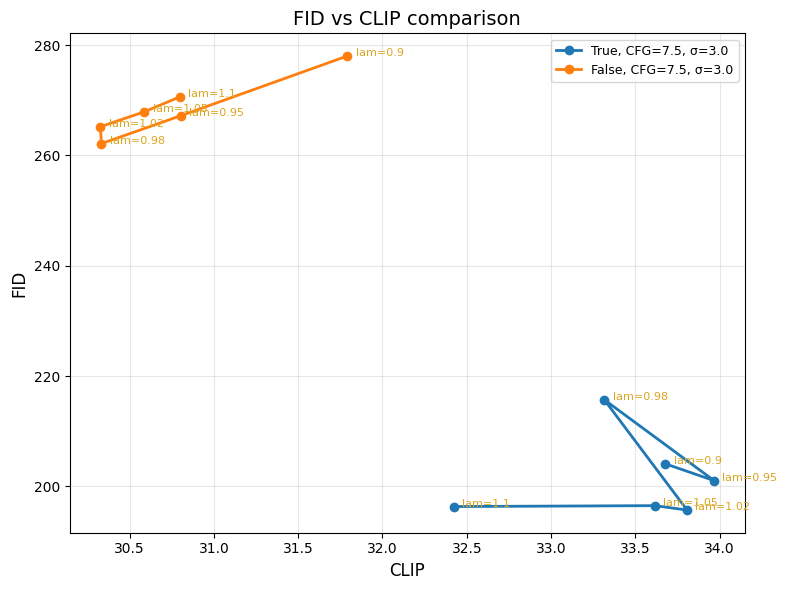

In [8]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for alg in replica_exchanges:
    tsr_lam_vals    = sorted(tsr_results[alg].keys(), reverse=True)
    tsr_clip_vals = [tsr_results[alg][lam][1] for lam in tsr_lam_vals]
    tsr_fid_vals  = [tsr_results[alg][lam][0] for lam in tsr_lam_vals]

    ax.plot(tsr_clip_vals, tsr_fid_vals, marker="o", linewidth=2, label=f"{alg}, CFG=7.5, σ=3.0")
    for lam in tsr_lam_vals:
        f, c = tsr_results[alg][lam]
        ax.annotate(f"lam={lam}", (c, f), textcoords="offset points", xytext=(6, 0), fontsize=8, color="goldenrod")

ax.set_xlabel("CLIP", fontsize=12)
ax.set_ylabel("FID", fontsize=12)
ax.set_title("FID vs CLIP comparison", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fid_vs_clip.png", dpi=150)
plt.show()